# Seq2seq 

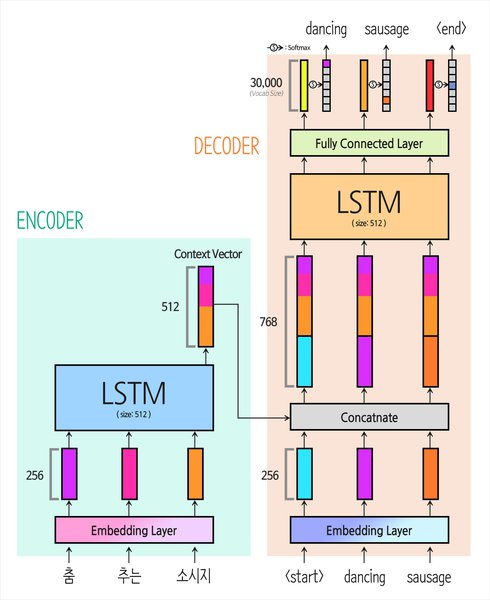

seq2seq 수식:  
$p(y_1, \ldots, y_{T'} \mid x_1, \ldots, x_T) = \prod_{t=1}^{T'} p(y_t \mid v, y_1, \ldots, y_{t-1})$

## LSTM Encoder

In [2]:
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        print("입력 Shape:", src.size())

        embedded = self.embedding(src)
        print("Embedding Layer를 거친 Shape:", embedded.size())

        outputs, (h_0, c_0) = self.rnn(embedded)
        print("LSTM Layer의 Output Shape:", outputs.size())
        print("LSTM Layer의 Hidden State Shape:", h_0.size())
        print("LSTM Layer의 Cell State Shape:", c_0.size())

        return outputs, h_0, c_0

print("슝~")

슝~


In [3]:
vocab_size = 30000
emb_size = 256
lstm_size = 512
batch_size = 1
sample_seq_len = 3

print("Vocab Size: {0}".format(vocab_size))
print("Embedidng Size: {0}".format(emb_size))
print("LSTM Size: {0}".format(lstm_size))
print("Batch Size: {0}".format(batch_size))
print("Sample Sequence Length: {0}\n".format(sample_seq_len))

Vocab Size: 30000
Embedidng Size: 256
LSTM Size: 512
Batch Size: 1
Sample Sequence Length: 3



In [4]:
import torch

encoder = Encoder(vocab_size, emb_size, lstm_size)
sample_input = torch.randint(0, vocab_size, (batch_size, sample_seq_len))

sample_output, hidden, cell = encoder(sample_input)

입력 Shape: torch.Size([1, 3])
Embedding Layer를 거친 Shape: torch.Size([1, 3, 256])
LSTM Layer의 Output Shape: torch.Size([1, 3, 512])
LSTM Layer의 Hidden State Shape: torch.Size([1, 1, 512])
LSTM Layer의 Cell State Shape: torch.Size([1, 1, 512])


## LSTM Decoder

In [5]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden, cell, context):
        print("입력 Shape:", x.size())

        embedded = self.embedding(x)
        print("Embedding Layer를 거친 Shape:", embedded.size())

        embedded = torch.cat((embedded, context), dim=2)
        print("Context Vector가 더해진 Shape:", embedded.size())

        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        print("LSTM Layer의 Output Shape:", output.size())

        output = self.fc(output)
        print("Decoder 최종 Output Shape:", output.size())

        return output, hidden, cell

In [6]:
print("Vocab Size: {0}".format(vocab_size))
print("Embedidng Size: {0}".format(emb_size))
print("LSTM Size: {0}".format(lstm_size))
print("Batch Size: {0}".format(batch_size))
print("Sample Sequence Length: {0}\n".format(sample_seq_len))

Vocab Size: 30000
Embedidng Size: 256
LSTM Size: 512
Batch Size: 1
Sample Sequence Length: 3



In [7]:
decoder_input = torch.randint(0, vocab_size, (batch_size, sample_seq_len))  # (batch_size, seq_length)

decoder = Decoder(vocab_size, emb_size, lstm_size)

dec_output, hidden, cell = decoder(decoder_input, hidden, cell, sample_output)

입력 Shape: torch.Size([1, 3])
Embedding Layer를 거친 Shape: torch.Size([1, 3, 256])
Context Vector가 더해진 Shape: torch.Size([1, 3, 768])
LSTM Layer의 Output Shape: torch.Size([1, 3, 512])
Decoder 최종 Output Shape: torch.Size([1, 3, 30000])


## Attention